# 04 — SHAP Explainability
Phase 6. Global + local explanations for the saved Random Forest, using `shap.TreeExplainer` (exact and fast for tree models) at the Phase 5 production threshold (0.30).

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import shap

import sys
sys.path.append('..')
from src.load_data import load_raw_data
from src.preprocessing import load_preprocessor, split_raw_data
from src.explain import explain_prediction

MODEL_DIR = Path('../model')
with open(MODEL_DIR / "model_info.json") as f:
    model_info = json.load(f)
THRESHOLD = model_info["production_threshold"]
print("production threshold:", THRESHOLD)

production threshold: 0.3


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model + test set

In [2]:
df = load_raw_data()
X_train_raw, X_test_raw, y_train, y_test = split_raw_data(df)  # same split as Phase 3-5

preprocessor = load_preprocessor()
model = joblib.load(MODEL_DIR / "model.pkl")

X_test = preprocessor.transform(X_test_raw)
y_test = y_test.reset_index(drop=True)

feature_names_raw = preprocessor.named_steps["column_transform"].get_feature_names_out()
feature_names = [n.split("__", 1)[-1] for n in feature_names_raw]  # strip ColumnTransformer prefixes

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

print("X_test:", X_test.shape, "| features:", len(feature_names))

X_test: (6000, 38) | features: 38


## Global explanation
`shap.TreeExplainer` on the full test set — exact for tree ensembles, no sampling needed.

In [3]:
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)
shap_values_pos = shap_explanation[..., 1]  # positive ("default") class
shap_values_pos.feature_names = feature_names

print("shap values shape:", shap_values_pos.values.shape)

shap values shape: (6000, 38)


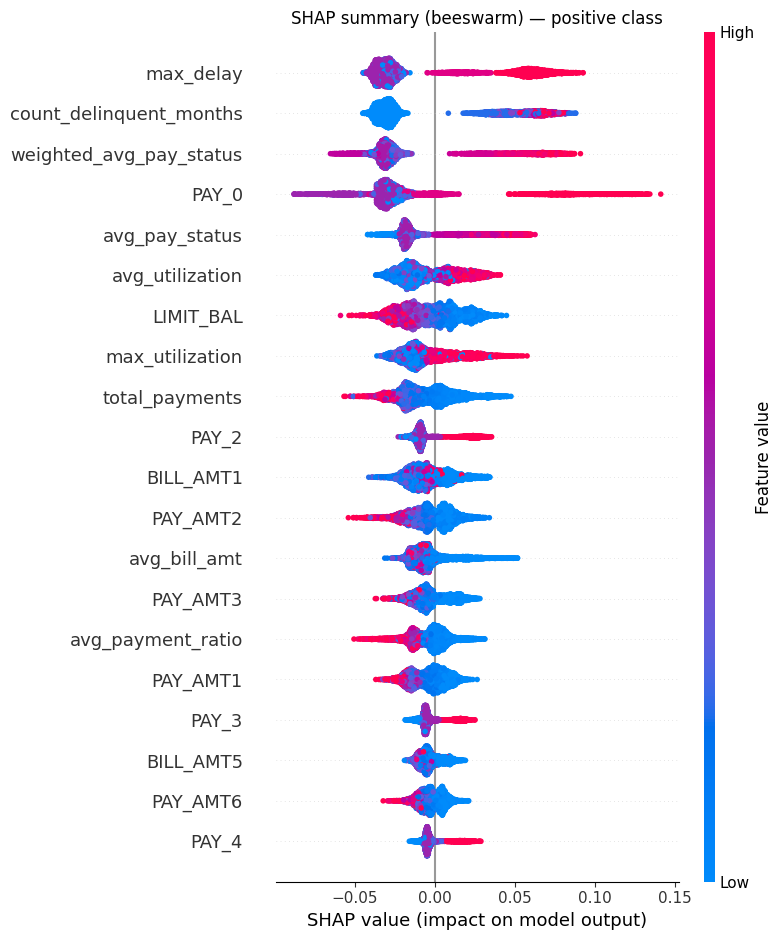

In [4]:
shap.summary_plot(shap_values_pos, X_test, feature_names=feature_names, show=False)
plt.title("SHAP summary (beeswarm) — positive class")
plt.tight_layout()
plt.show()

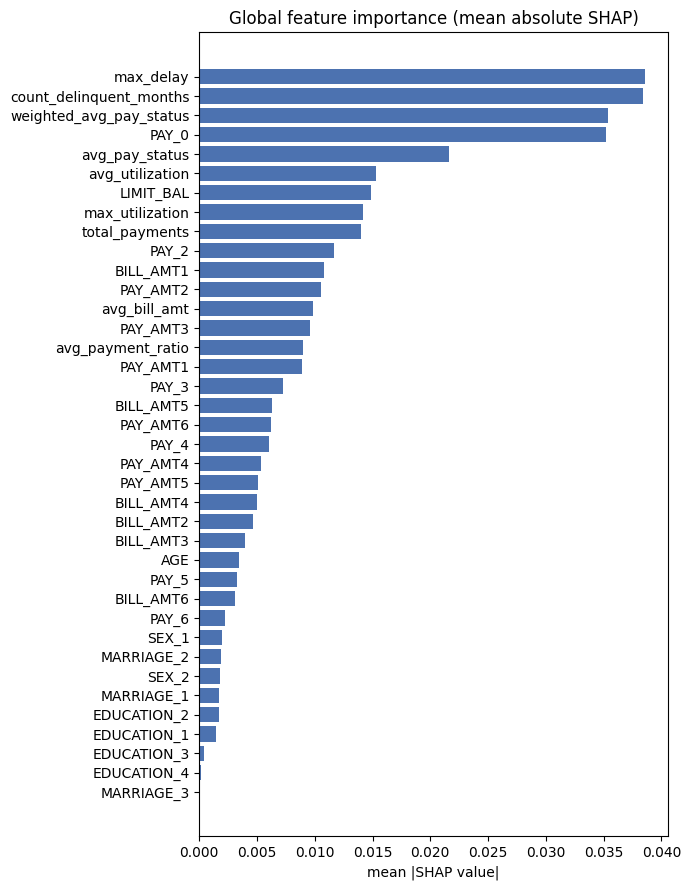

[('max_delay', np.float64(0.0386237692189188)),
 ('count_delinquent_months', np.float64(0.03843126531389128)),
 ('weighted_avg_pay_status', np.float64(0.03536257100776777)),
 ('PAY_0', np.float64(0.03523827116583593)),
 ('avg_pay_status', np.float64(0.02162540153451432)),
 ('avg_utilization', np.float64(0.015297463493716688)),
 ('LIMIT_BAL', np.float64(0.014868780431907386)),
 ('max_utilization', np.float64(0.014173762031296121)),
 ('total_payments', np.float64(0.014003219525488763)),
 ('PAY_2', np.float64(0.011662921424874654))]

In [5]:
mean_abs_shap = np.abs(shap_values_pos.values).mean(axis=0)
importance = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(7, 9))
names, vals = zip(*importance)
ax.barh(names[::-1], vals[::-1], color="#4C72B0")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Global feature importance (mean absolute SHAP)")
plt.tight_layout()
plt.show()

importance[:10]

### EDA comparison

This **confirms** the EDA's headline finding — repayment-status signal dominates. But it also **surfaces something the EDA missed**: the top four features by mean |SHAP| are `max_delay`, `count_delinquent_months`, `weighted_avg_pay_status`, and *then* raw `PAY_0` in 4th place. The three engineered Phase 3 aggregates each individually outrank the raw `PAY_0` column that the EDA flagged as the single strongest predictor — summarizing repayment behavior across all 6 months (how many months delinquent, how bad was the worst one, a recency-weighted average) carries more model-usable signal than any one month's snapshot on its own, including the most recent one.

## Local explanations
Three test-set examples at the production threshold (0.30): a confident true positive, the most confidently-wrong false positive, and a confident true negative.

In [6]:
tp_mask = (y_test.values == 1) & (y_pred == 1)
fp_mask = (y_test.values == 0) & (y_pred == 1)
tn_mask = (y_test.values == 0) & (y_pred == 0)

tp_idx = int(np.argmax(np.where(tp_mask, y_proba, -1)))       # highest-confidence true positive
fp_idx = int(np.argmax(np.where(fp_mask, y_proba, -1)))       # most confidently-wrong false positive
tn_idx = int(np.argmin(np.where(tn_mask, y_proba, 2)))        # lowest-risk true negative

examples = {"true_positive": tp_idx, "false_positive": fp_idx, "true_negative": tn_idx}
for label, idx in examples.items():
    print(f"{label}: row {idx}, y_true={y_test.values[idx]}, y_pred={y_pred[idx]}, proba={y_proba[idx]:.4f}")

true_positive: row 2695, y_true=1, y_pred=1, proba=0.9830
false_positive: row 5028, y_true=0, y_pred=1, proba=0.9806
true_negative: row 3904, y_true=0, y_pred=0, proba=0.0493


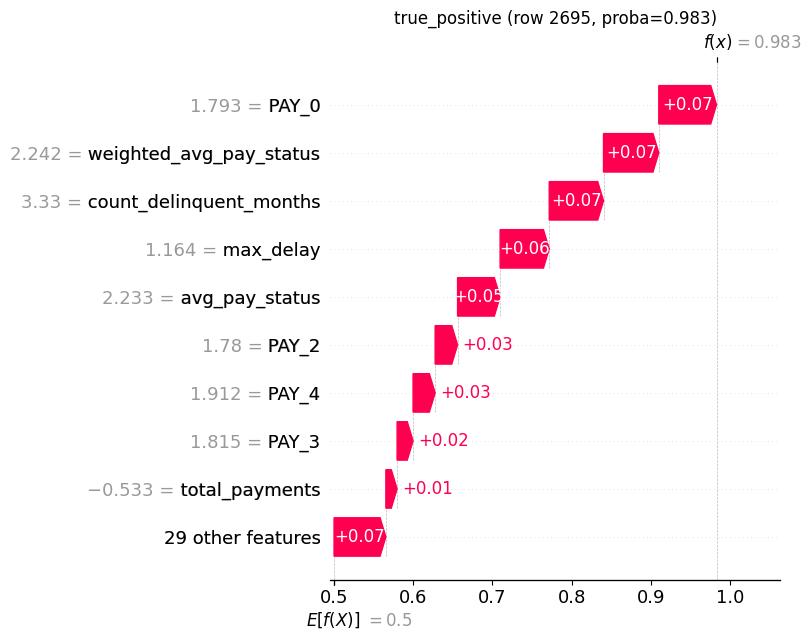

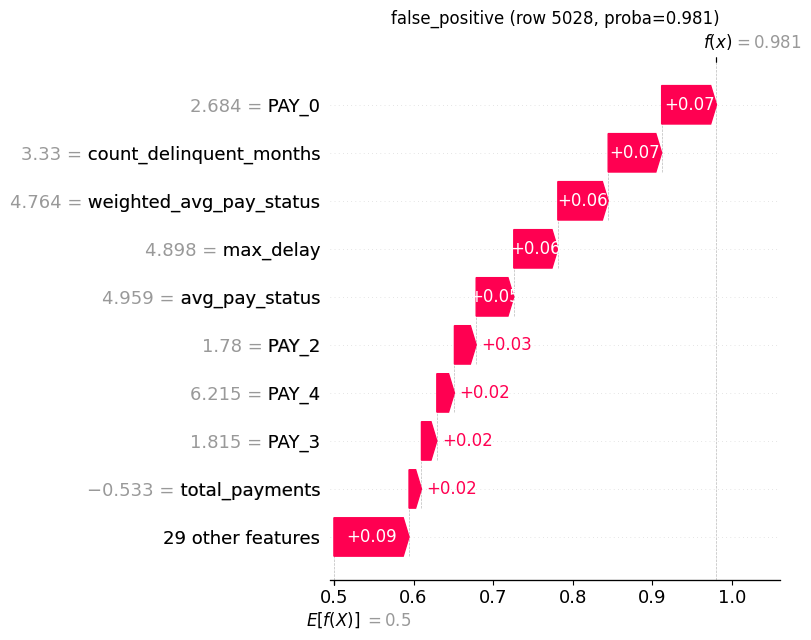

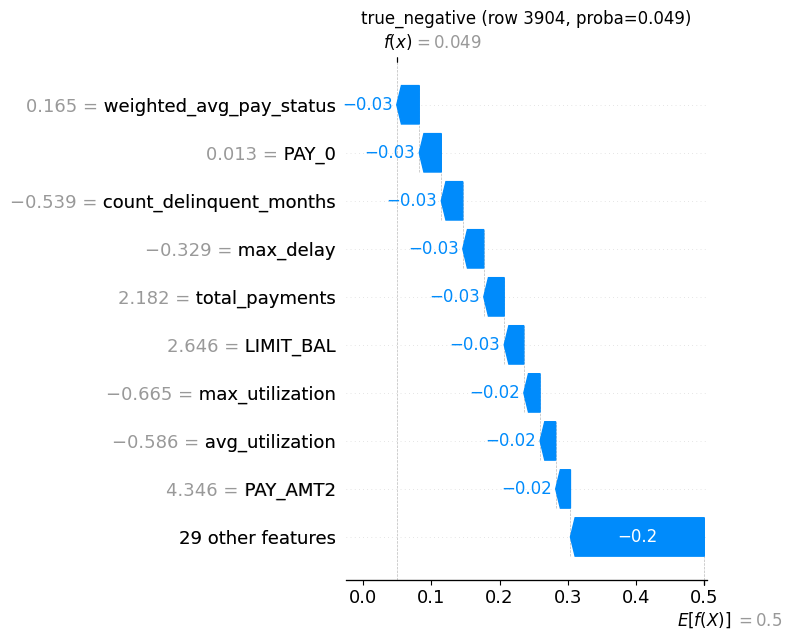

In [7]:
for label, idx in examples.items():
    shap.plots.waterfall(shap_values_pos[idx], show=False)
    plt.title(f"{label} (row {idx}, proba={y_proba[idx]:.3f})")
    plt.tight_layout()
    plt.show()

### Tested via `src/explain.py`'s `explain_prediction`
This is the same function Phase 7's API will call — exercised here on the three example rows, not just written and hoped to work.

In [8]:
explanations = {}
for label, idx in examples.items():
    result = explain_prediction(model, X_test[idx], feature_names, top_n=3)
    explanations[label] = result
    print(f"\n{label} (row {idx}):")
    print(json.dumps(result, indent=2))


true_positive (row 2695):
{
  "prediction_proba": 0.9830344328789015,
  "top_contributors": [
    {
      "feature": "PAY_0",
      "value": 1.793311030253686,
      "contribution": 0.07290311116999094,
      "direction": "increases risk"
    },
    {
      "feature": "weighted_avg_pay_status",
      "value": 2.242186203883917,
      "contribution": 0.06980131769801388,
      "direction": "increases risk"
    },
    {
      "feature": "count_delinquent_months",
      "value": 3.33009205620407,
      "contribution": 0.06854570064537488,
      "direction": "increases risk"
    }
  ]
}

false_positive (row 5028):
{
  "prediction_proba": 0.9805625096069548,
  "top_contributors": [
    {
      "feature": "PAY_0",
      "value": 2.683678326351836,
      "contribution": 0.06888794718623165,
      "direction": "increases risk"
    },
    {
      "feature": "count_delinquent_months",
      "value": 3.33009205620407,
      "contribution": 0.0671600757244212,
      "direction": "increases risk"


### Plain-English narration

- **True positive (row 2695, 98.3% predicted risk):** flagged mainly due to a delinquent most-recent payment status (`PAY_0`), a recency-weighted repayment score well above average (`weighted_avg_pay_status`), and multiple delinquent months in the last six (`count_delinquent_months`) — a genuinely high-risk borrower, correctly caught.
- **False positive (row 5028, 98.1% predicted risk):** flagged on *the same three features*, at similarly extreme values (an even worse `PAY_0` and `weighted_avg_pay_status` than the true positive above) — this customer's repayment history looked just as bad on paper, but they didn't actually default. This isn't a missing-feature problem; severe past delinquency correlates with but doesn't guarantee a future default, and this is exactly the kind of case the model will get wrong.
- **True negative (row 3904, 4.9% predicted risk):** correctly cleared, driven by an on-time most-recent payment status, essentially no delinquent months (`count_delinquent_months` below average), and a low recency-weighted repayment score — a clean repayment history across the board.

## Summary

- Global SHAP importance confirms the EDA: repayment-status features dominate, far ahead of `LIMIT_BAL`, utilization, or demographics.
- It also refines the EDA's finding — the Phase 3 engineered aggregates (`max_delay`, `count_delinquent_months`, `weighted_avg_pay_status`) each outrank the raw `PAY_0` column individually, meaning the 6-month summary features are doing real work, not just convenience.
- The true-positive/false-positive pair shows the model's realistic failure mode: it can't distinguish two customers with near-identical severe delinquency histories when only one of them actually defaults — the top SHAP drivers are essentially the same for both.
- `src/explain.py`'s `explain_prediction(model, preprocessed_row, feature_names, top_n)` was exercised on all three example rows above (not just written standalone) and returns a plain dict with `prediction_proba` and a JSON-serializable `top_contributors` list — ready for Phase 7's `/predict` endpoint to call directly.